# Análise dos logs

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [19]:
def plot_congestion_control(df):
        fig, ax = plt.subplots(figsize=(14, 7))

        # 1. Configuração dos Tickers (O ponto chave da sua solicitação)
        # Define marcas principais a cada 0.1s
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
        # Opcional: marcas menores (minors) a cada 0.05s para dar mais detalhe
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))

        # 2. Plotagem dos dados
        ax.plot(df['tempo_relativo'], df['cwnd'], label='CWND', 
                color='#1f77b4', linewidth=2, drawstyle='steps-post')

        ax.step(df['tempo_relativo'], df['ssthresh'], label='SSTHRESH', 
                color='#ff7f0e', linestyle='--', where='post')

        # 3. Estilização do Grid
        # Ativa grid nas marcas principais e secundárias para facilitar a precisão visual
        ax.grid(True, which='major', linestyle='-', alpha=0.5)
        ax.grid(True, which='minor', linestyle=':', alpha=0.3)

        # 4. Destaque de Timeouts
        timeouts = df[df['evento'] == 'TIMEOUT']
        ax.scatter(timeouts['tempo_relativo'], timeouts['cwnd'], 
                color='red', marker='X', s=100, label='Perda/Timeout', zorder=5)

        # 5. Labels e Títulos
        ax.set_title('Análise Detalhada de Congestionamento (Intervalos de 0.1s)', fontsize=14)
        ax.set_xlabel('Tempo Relativo (s)', fontsize=12)
        ax.set_ylabel('Tamanho da Janela (Bytes)', fontsize=12)
        ax.legend(loc='upper right')

        # Rotacionar os labels do eixo X se ficarem muito apertados
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

In [20]:
df = pd.read_csv("client_log.csv")

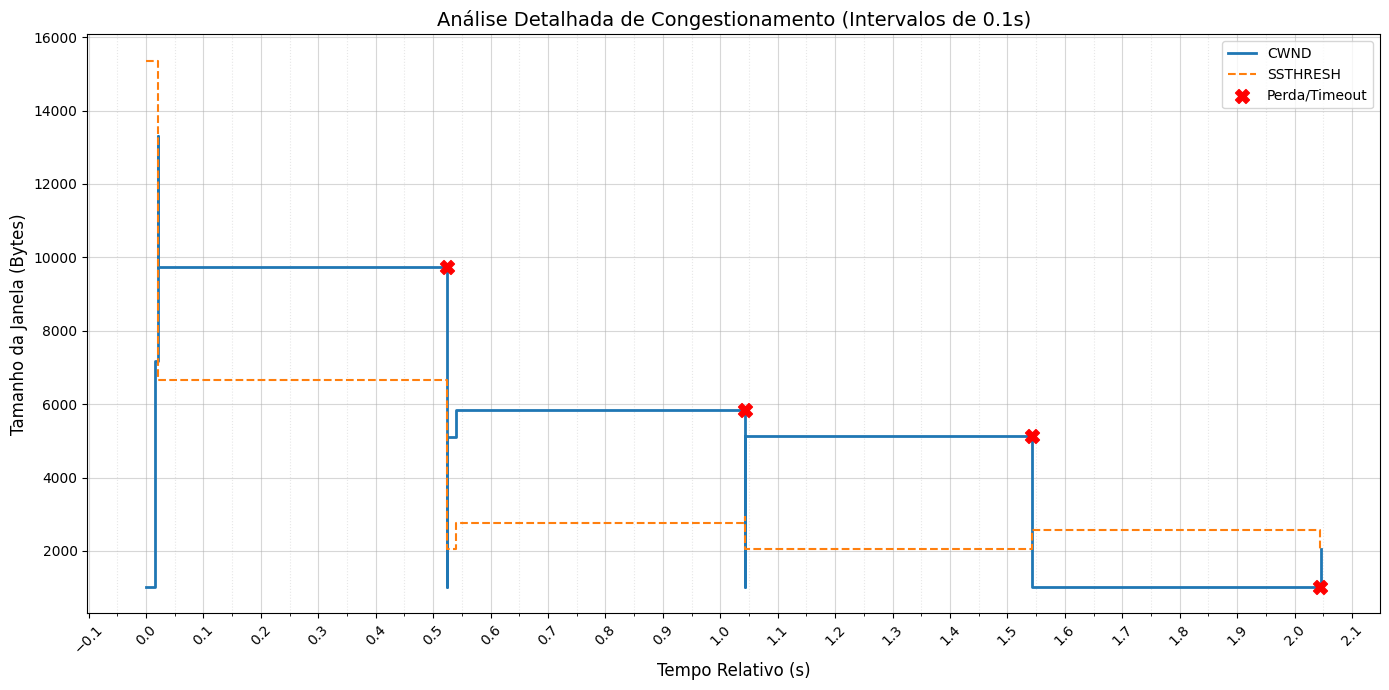

In [21]:
plot_congestion_control(df)